In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
CA1_path <- paste0(indir,"/07_H3K27me3_Allsubclass/CA1/")
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L2_3.mm10.tmp"   
[2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L4_Rorb.mm10.tmp"
[3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L5.mm10.tmp"     
[4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L6.mm10.tmp"     
[5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_CA1.mm10.tmp"    
[6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_CA23.mm10.tmp"   
[7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_DG.mm10.tmp"     
[8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_In_Pvalb.mm10.tmp"  
[9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27me3_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27me3_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27me3_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27me3_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,L6_signal_sum_log10,CA1_signal_sum,CA1_signal_sum_log10,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,74.20880,1.8762687,153.69740,2.189483,0.000,0.000000,0.000000,0.0000000,0.00000,0.000000,59.65880,1.782894,0.000000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:3868330-3869330,0.00000,0.0000000,0.00000,0.000000,0.000,0.000000,0.000000,0.0000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:4000851-4001851,0.00000,0.0000000,0.00000,0.000000,0.000,0.000000,0.000000,0.0000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:4017553-4018553,53.69007,1.7379085,76.84880,1.891252,0.000,0.000000,61.163099,1.7935327,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,141.6319,2.154217,0.00000,0.000000
chr1:4168027-4169027,0.00000,0.0000000,0.00000,0.000000,0.000,0.000000,0.000000,0.0000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:4249638-4250638,37.10440,1.5809751,153.69740,2.189483,0.000,0.000000,87.297668,1.9459492,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:4454449-4455449,102.22251,2.0137744,0.00000,0.000000,2079.140,3.318093,0.000000,0.0000000,0.00000,0.000000,0.00000,0.000000,63.043400,1.8064744,0.0000,0.000000,0.00000,0.000000
chr1:4794017-4795017,0.00000,0.0000000,0.00000,0.000000,0.000,0.000000,0.000000,0.0000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.00000,0.000000
chr1:5336791-5337791,37.10440,1.5809751,76.84880,1.891252,0.000,0.000000,0.000000,0.0000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.00000,0.000000


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.8762687,2.189483,0.000000,0.0000000,0.000000,1.782894,0.0000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4017553-4018553,1.7379085,1.891252,0.000000,1.7935327,0.000000,0.000000,0.0000000,2.154217,0.000000
chr1:4168027-4169027,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4249638-4250638,1.5809751,2.189483,0.000000,1.9459492,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4454449-4455449,2.0137744,0.000000,3.318093,0.0000000,0.000000,0.000000,1.8064744,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.8762687,2.189483,0.000000,0.0000000,0.000000,1.782894,0.0000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4017553-4018553,1.7379085,1.891252,0.000000,1.7935327,0.000000,0.000000,0.0000000,2.154217,0.000000
chr1:4168027-4169027,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4249638-4250638,1.5809751,2.189483,0.000000,1.9459492,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4454449-4455449,2.0137744,0.000000,3.318093,0.0000000,0.000000,0.000000,1.8064744,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,L2_3,L4_Rorb,L5,L6,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.8762687,2.189483,0.000000,0.0000000,0.000000,1.782894,0.0000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4017553-4018553,1.7379085,1.891252,0.000000,1.7935327,0.000000,0.000000,0.0000000,2.154217,0.000000
chr1:4168027-4169027,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4249638-4250638,1.5809751,2.189483,0.000000,1.9459492,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4454449-4455449,2.0137744,0.000000,3.318093,0.0000000,0.000000,0.000000,1.8064744,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,L2_3,L4,L5,L6,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.8762687,2.189483,0.000000,0.0000000,0.000000,1.782894,0.0000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4017553-4018553,1.7379085,1.891252,0.000000,1.7935327,0.000000,0.000000,0.0000000,2.154217,0.000000
chr1:4168027-4169027,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4249638-4250638,1.5809751,2.189483,0.000000,1.9459492,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4454449-4455449,2.0137744,0.000000,3.318093,0.0000000,0.000000,0.000000,1.8064744,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,L2_3,L4,CA1,CA23,DG,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.8762687,2.189483,0.000000,1.782894,0.0000000,0.000000,0.000000,0.0000000
chr1:3868330-3869330,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000
chr1:4017553-4018553,1.7379085,1.891252,0.000000,0.000000,0.0000000,2.154217,0.000000,0.8967663
chr1:4168027-4169027,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000
chr1:4249638-4250638,1.5809751,2.189483,0.000000,0.000000,0.0000000,0.000000,0.000000,0.9729746
chr1:4454449-4455449,2.0137744,0.000000,0.000000,0.000000,1.8064744,0.000000,0.000000,1.6590463
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","DG","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","DG","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "DG"    "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.8762687,2.189483,0.0000000,0.000000,1.782894,0.0000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4017553-4018553,1.7379085,1.891252,0.8967663,0.000000,0.000000,0.0000000,2.154217,0.000000
chr1:4168027-4169027,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4249638-4250638,1.5809751,2.189483,0.9729746,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4454449-4455449,2.0137744,0.000000,1.6590463,0.000000,0.000000,1.8064744,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
.,1.004171,0.7728355,0.3834242,0.6699846,0.7236865,0.7123604,0.3309907,0.3053111


In [19]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3","L4","L5","CA1","CA23","DG","Pvalb","Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K27me3_path <- paste0(indir,"/07_H3K27me3_Allsubclass/")

In [21]:
subdirs <- list.dirs(path = H3K27me3_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//DG"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//L2_3" 
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//L4_5" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//L5"   
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//Lamp5"
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//Pvalb"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//Sncg" 
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/07_H3K27me3_Allsubclass//Sst"

In [22]:
basename(subdirs)

[1] "CA1"   "CA23"  "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "Pvalb" "Sncg" 
[10] "Sst"

In [ ]:
L2_3 <- process_files(paste0(indir,'/07_H3K27me3_Allsubclass/L2_3'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:40205252-40206252,2.366758,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:63801436-63802436,1.234960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:95910578-95911578,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:121992418-121993418,1.729279,0.000000,0.000000,0.000000,1.782894,1.806474,2.502222,2.593831
chr1:123860055-123861055,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:127035082-127036082,1.876269,0.000000,1.526826,0.000000,0.000000,2.104100,0.000000,0.000000
chr1:165699424-165700424,2.257395,2.748067,2.999101,2.499651,2.834129,2.829504,0.000000,0.000000
chr1:184865166-184866166,1.580975,1.891252,1.330180,0.000000,0.000000,2.104100,2.026099,0.000000
chr2:10595247-10596247,0.000000,1.300631,0.000000,2.770036,1.196887,2.104100,0.000000,0.000000


In [24]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,0.7449541,0.5614042,0.3865713,0.6923241,0.6135638,0.7414387,0.3496621,0.2437166


In [ ]:
L4_5 <- process_files(paste0(indir,'/07_H3K27me3_Allsubclass/L4_5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3989606-3990606,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7536517-7537517,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:9780815-9781815,1.580975,1.803674,0.000000,1.832974,2.476098,2.104100,2.502222,0.000000
chr1:14839073-14840073,0.000000,1.891252,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:14914779-14915779,2.251204,2.138978,2.382440,2.933550,2.563331,2.438413,2.802567,3.037011
chr1:17756423-17757423,0.000000,0.000000,0.000000,0.000000,1.782894,0.000000,0.000000,0.000000
chr1:22023298-22024298,0.000000,0.000000,0.000000,0.000000,0.000000,2.080642,0.000000,0.000000
chr1:23137109-23138109,1.532245,0.000000,0.000000,0.000000,0.000000,0.000000,2.452267,0.000000
chr1:26269966-26270966,2.035544,1.876425,1.307180,0.000000,1.782894,1.806474,0.000000,0.000000


In [26]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L4_5,0.9392878,0.687865,0.3427989,0.7486738,0.7920879,0.7597708,0.3218087,0.2381195


In [ ]:
L5 <- process_files(paste0(indir,'/07_H3K27me3_Allsubclass/L5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4185672-4186672,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:9994550-9995550,1.580975,2.1894830,1.0696722,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:20083023-20084023,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:22220457-22221457,1.580975,0.0000000,0.9014942,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:25591789-25592789,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:26496284-26497284,1.933216,2.1234348,1.0696722,0.0000000,1.2538975,2.132453,0.000000,0.000000
chr1:27086331-27087331,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,2.593831
chr1:27631906-27632906,0.000000,0.0000000,0.0000000,0.8636109,0.0000000,0.000000,0.000000,0.000000
chr1:27648468-27649468,1.580975,0.0000000,0.0000000,0.0000000,1.7828938,1.806474,0.000000,0.000000


In [28]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L5,0.9143926,0.6032028,0.3500726,0.6317737,0.6538284,0.6853426,0.3046919,0.2200581


In [ ]:
CA1 <- process_files(paste0(indir,'/07_H3K27me3_Allsubclass/CA1'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.8762687,2.189483,0.0000000,0.000000,1.782894,0.0000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4017553-4018553,1.7379085,1.891252,0.8967663,0.000000,0.000000,0.0000000,2.154217,0.000000
chr1:4168027-4169027,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4249638-4250638,1.5809751,2.189483,0.9729746,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4454449-4455449,2.0137744,0.000000,1.6590463,0.000000,0.000000,1.8064744,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000


In [30]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
CA1,1.004171,0.7728355,0.3834242,0.6699846,0.7236865,0.7123604,0.3309907,0.3053111


In [ ]:
CA23 <- process_files(paste0(indir,'/07_H3K27me3_Allsubclass/CA23'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3151305-3152305,0.0000000,0.000000,0.0000000,1.832974,0.000000,1.806474,0.000000,0.000000
chr1:3776523-3777523,1.3097494,0.000000,0.0000000,1.557255,0.000000,1.806474,0.000000,0.000000
chr1:4031436-4032436,1.7710822,0.000000,0.0000000,0.000000,0.000000,1.562964,0.000000,0.000000
chr1:4057009-4058009,0.0000000,1.887376,0.0000000,1.829105,2.251311,0.000000,0.000000,0.000000
chr1:4065207-4066207,0.9385503,1.891252,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4072107-4073107,1.8278115,0.000000,0.0000000,0.000000,1.782894,0.000000,0.000000,0.000000
chr1:4118129-4119129,0.0000000,0.000000,0.0000000,0.000000,0.000000,1.806474,0.000000,0.000000
chr1:4149321-4150321,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4342915-4343915,0.0000000,0.000000,0.5507114,0.000000,0.000000,0.000000,0.000000,0.000000


In [32]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
CA23,1.154688,0.8958381,0.4244999,0.8504938,0.8584892,0.8452078,0.3767595,0.3254102


In [ ]:
DG <- process_files(paste0(indir,'/07_H3K27me3_Allsubclass/DG'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:5012521-5013521,2.050431,0.000000,0.0000000,2.305820,2.180125,2.645721,0.000000,0.000000
chr1:6862606-6863606,2.416191,2.603723,2.5315321,2.835015,2.985959,1.806474,0.000000,0.000000
chr1:7358520-7359520,0.000000,0.000000,0.0000000,0.000000,0.000000,2.104100,0.000000,0.000000
chr1:13910825-13911825,2.050431,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:16814367-16815367,0.000000,1.891252,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:17029988-17030988,0.000000,1.896366,0.3159207,1.827808,2.080329,2.273835,0.000000,0.000000
chr1:17078363-17079363,1.391561,2.189483,1.2193977,0.000000,2.621812,1.806474,0.000000,0.000000
chr1:19954555-19955555,1.876269,0.000000,2.6904268,0.000000,2.030167,0.000000,0.000000,0.000000
chr1:27743954-27744954,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [34]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
DG,1.225519,0.934219,0.4835305,0.9215396,0.9246,0.7758826,0.3283098,0.3686846


In [ ]:
Pvalb <- process_files(paste0(indir,'/07_H3K27me3_Allsubclass/Pvalb'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3168678-3169678,0.000000,0.000000,0.0000000,0.000000,0.0000000,1.8064744,0.000000,0.000000
chr1:3188267-3189267,0.000000,0.000000,0.0000000,1.566047,0.0000000,0.0000000,0.000000,0.000000
chr1:3189154-3190154,0.000000,0.000000,0.0000000,2.130802,0.0000000,0.0000000,0.000000,0.000000
chr1:3229735-3230735,0.000000,1.329702,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:3257828-3258828,1.876269,1.152838,0.0000000,0.000000,1.7828938,0.0000000,0.000000,0.000000
chr1:3275051-3276051,0.000000,0.000000,0.0000000,1.832974,0.0000000,0.0000000,2.479562,0.000000
chr1:3277592-3278592,1.361082,0.000000,0.0000000,2.032538,0.0000000,0.0000000,0.000000,0.000000
chr1:3343546-3344546,1.930577,0.000000,1.0696722,0.000000,1.9432169,0.0000000,0.000000,2.894308
chr1:3345473-3346473,0.000000,0.000000,0.0000000,0.000000,1.5110834,0.0000000,0.000000,2.777289


In [36]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
Pvalb,1.188643,0.8937116,0.4381634,0.9077146,0.940946,0.9073911,0.3854766,0.3148027


In [ ]:
Sst <- process_files(paste0(indir,'/07_H3K27me3_Allsubclass/Sst'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3074178-3075178,1.876269,0.000000,1.027449,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:3083989-3084989,1.580975,2.189483,0.000000,0.000000,1.7828938,0.000000,0.000000,2.593831
chr1:3091016-3092016,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:3096626-3097626,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:3098325-3099325,0.000000,0.000000,1.177285,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:3104126-3105126,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:3105267-3106267,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:3133078-3134078,2.338133,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,1.498812
chr1:3135638-3136638,1.580975,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,2.593831


In [38]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
Sst,1.183026,0.8856359,0.4330026,0.8902733,0.9401808,0.8907621,0.3745407,0.3366257


In [39]:
# all <- rbind(L2_3,L4_5,L5,CA1,CA23,DG,Pvalb,Sst)
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,DG_mean,Pvalb_mean,Sst_mean)

In [40]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,0.7449541,0.5614042,0.3865713,0.6923241,0.6135638,0.7414387,0.3496621,0.2437166
L4_5,0.9392878,0.6878650,0.3427989,0.7486738,0.7920879,0.7597708,0.3218087,0.2381195
L5,0.9143926,0.6032028,0.3500726,0.6317737,0.6538284,0.6853426,0.3046919,0.2200581
CA1,1.0041710,0.7728355,0.3834242,0.6699846,0.7236865,0.7123604,0.3309907,0.3053111
CA23,1.1546881,0.8958381,0.4244999,0.8504938,0.8584892,0.8452078,0.3767595,0.3254102
DG,1.2255190,0.9342190,0.4835305,0.9215396,0.9246000,0.7758826,0.3283098,0.3686846


[1] 8 8

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,0.7449541,0.5614042,0.3865713,0.6923241,0.6135638,0.7414387,0.3496621,0.2437166
L4_5,0.9392878,0.6878650,0.3427989,0.7486738,0.7920879,0.7597708,0.3218087,0.2381195
L5,0.9143926,0.6032028,0.3500726,0.6317737,0.6538284,0.6853426,0.3046919,0.2200581
CA1,1.0041710,0.7728355,0.3834242,0.6699846,0.7236865,0.7123604,0.3309907,0.3053111
CA23,1.1546881,0.8958381,0.4244999,0.8504938,0.8584892,0.8452078,0.3767595,0.3254102
DG,1.2255190,0.9342190,0.4835305,0.9215396,0.9246000,0.7758826,0.3283098,0.3686846
Pvalb,1.1886428,0.8937116,0.4381634,0.9077146,0.9409460,0.9073911,0.3854766,0.3148027
Sst,1.1830257,0.8856359,0.4330026,0.8902733,0.9401808,0.8907621,0.3745407,0.3366257


In [41]:
heatmap_matrix <- as.matrix(all)

In [42]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,0.7449541,0.5614042,0.3865713,0.6923241,0.6135638,0.7414387,0.3496621,0.2437166
L4_5,0.9392878,0.6878650,0.3427989,0.7486738,0.7920879,0.7597708,0.3218087,0.2381195
L5,0.9143926,0.6032028,0.3500726,0.6317737,0.6538284,0.6853426,0.3046919,0.2200581
CA1,1.0041710,0.7728355,0.3834242,0.6699846,0.7236865,0.7123604,0.3309907,0.3053111
CA23,1.1546881,0.8958381,0.4244999,0.8504938,0.8584892,0.8452078,0.3767595,0.3254102
DG,1.2255190,0.9342190,0.4835305,0.9215396,0.9246000,0.7758826,0.3283098,0.3686846
Pvalb,1.1886428,0.8937116,0.4381634,0.9077146,0.9409460,0.9073911,0.3854766,0.3148027
Sst,1.1830257,0.8856359,0.4330026,0.8902733,0.9401808,0.8907621,0.3745407,0.3366257


In [43]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [44]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,-1.32309886,-0.91296082,0.8415694084,0.14470366,-0.8709903,0.5275983,1.6274445,-0.03426581
L4_5,0.10109071,0.06999128,-1.6414115636,0.78395046,1.3941722,0.7371382,-0.4531430,-0.99178833
L5,2.17470816,0.01520417,0.2948315752,-0.65494610,0.2426885,-0.2784074,-0.9632407,-0.83083823
CA1,0.51978717,0.97120940,-0.0009718744,-1.33838705,-0.4099462,-1.1509584,-0.1641343,1.57340126
CA23,0.07155132,0.80989619,-1.1129246984,-0.51109431,-1.1119154,0.2039668,1.8738456,-0.22332552
DG,0.33445560,0.33612050,1.0671465014,0.42802902,0.1352197,-1.2452259,-1.8176364,0.76189099
Pvalb,-0.27075978,-0.45044055,-0.7429362358,0.23463626,0.2796700,1.4614836,1.1174431,-1.62909644
Sst,-0.30464195,-0.72690565,-1.4933195205,-0.03015864,0.7761544,1.8043509,0.3676982,-0.39317780


In [45]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


In [46]:
library(grid)

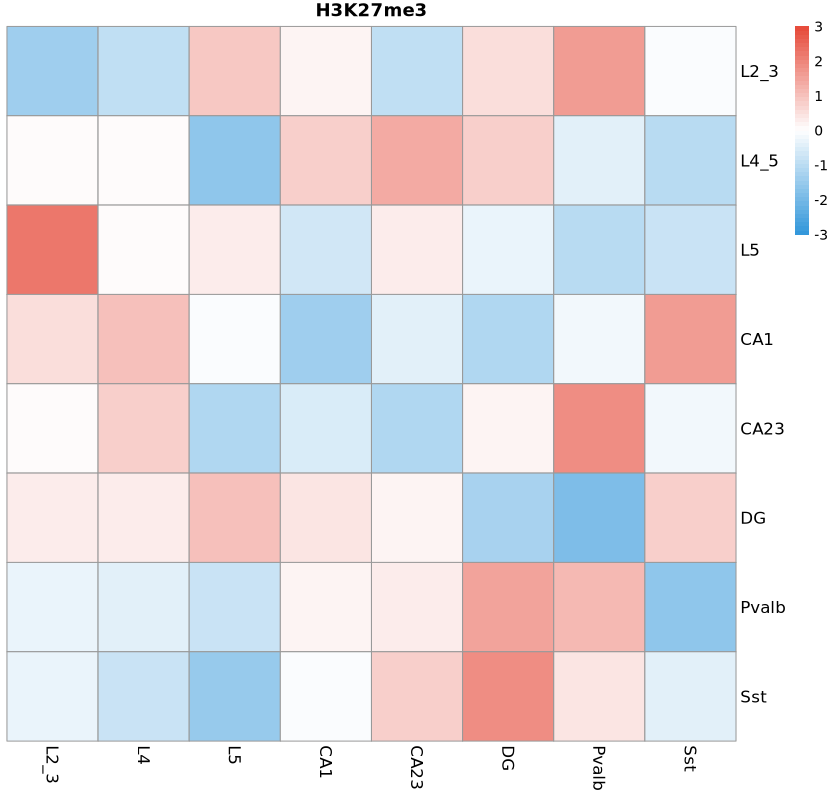

In [47]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

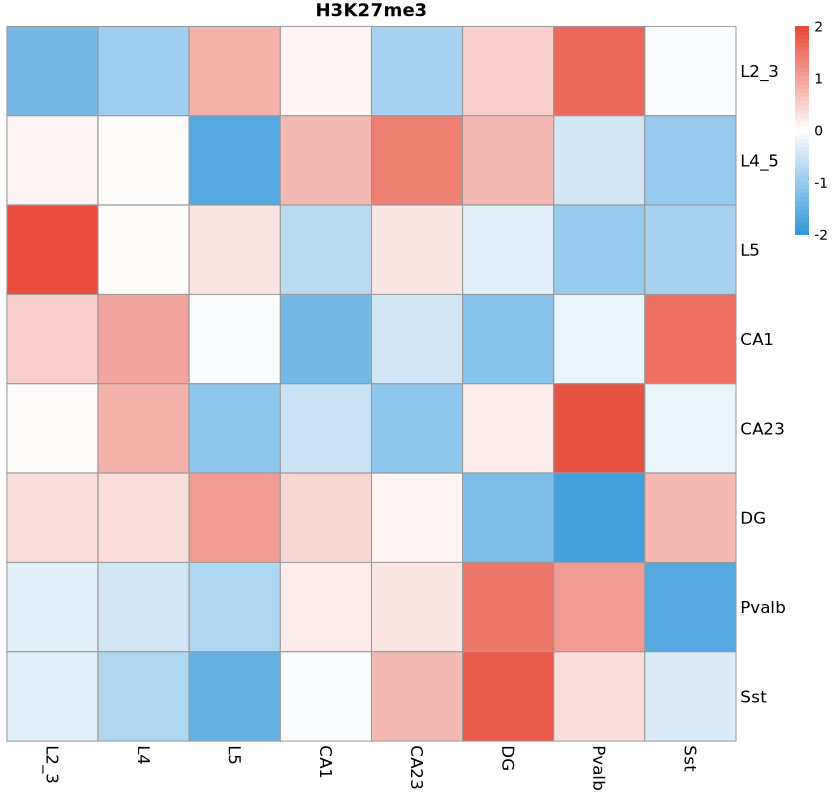

In [48]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

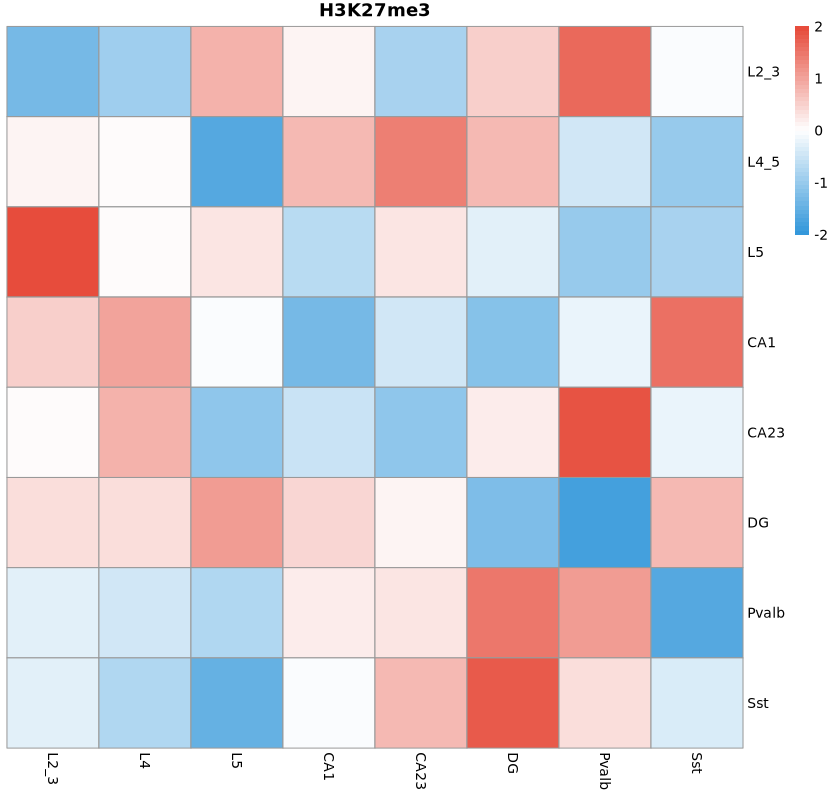

In [49]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27me3",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

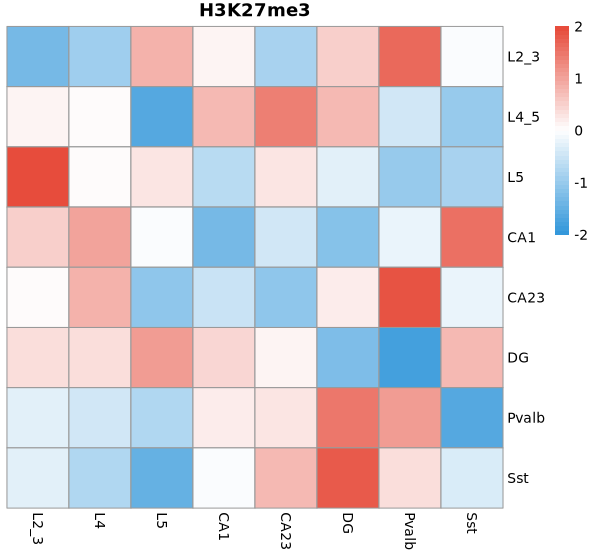

In [50]:
options(repr.plot.width = 6, repr.plot.height = 5.6, repr.plot.res = 100)
p1

In [ ]:
pdf("../../../output/01-youth/07-Histone/01-heatmap/12-H3K27me3_modification_in_hyperDHMR_merge_v3.pdf",width = 6,height = 5.6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!